# LC Notebook Diff E2E Test - Basic Functionality on NBClassic

- Test that LC Notebook Diff extension works properly on NBClassic
- Verify that Diff tab is accessible
- Verify that file selection and diff display work correctly

In [16]:
nbclassic_url = "http://localhost:8888/nbclassic/tree?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [17]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpv8sr63dc'

In [18]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.jupyterlab as jupyterlab
importlib.reload(jupyterlab)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251114-191231',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmppj4idey7')

## Open NBClassic and wait for it to load

Start epoch: 1763115151.4701471 seconds
NBClassic loaded successfully


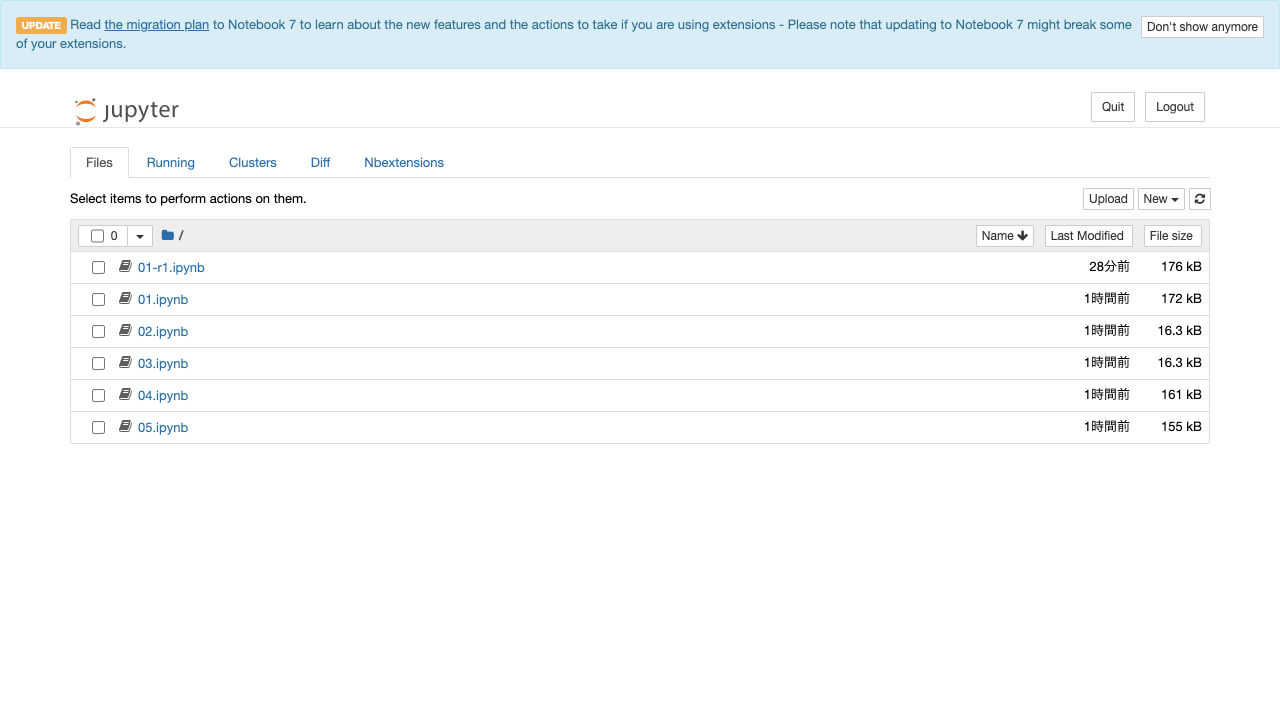

In [19]:
nbclassic_page = None

async def _step(page):
    await page.goto(nbclassic_url)

    # Wait for NBClassic file browser to load
    # NBClassic uses #notebook_list for file listing
    await expect(page.locator('#notebook_list')).to_be_visible(timeout=transition_timeout)

    global nbclassic_page
    nbclassic_page = page
    
    print("NBClassic loaded successfully")

await run_pw(_step)

## Click on Diff tab to open Diff widget

Start epoch: 1763115151.983766 seconds
Clicked on Diff tab
Diff tab content is visible


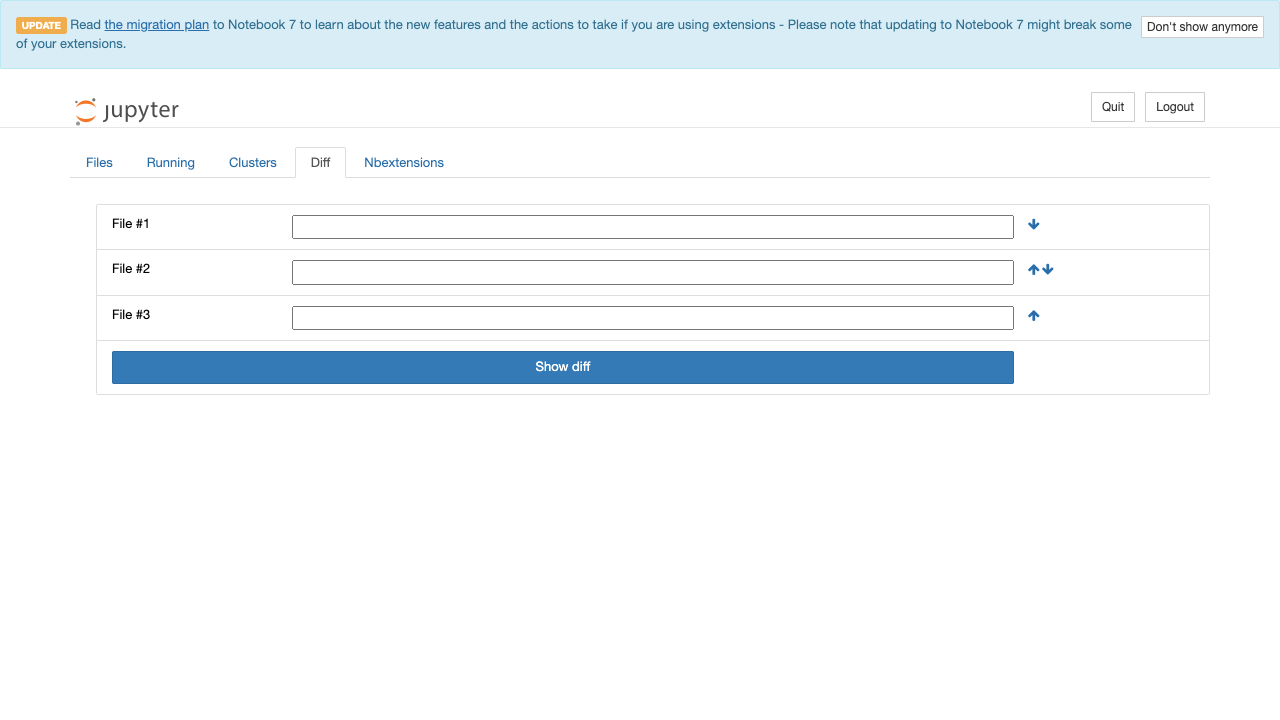

In [20]:
async def _step(page):
    # In NBClassic, Diff tab is added to #tabs
    # Tab link has href="#notebook_diff" (from main.js:143-149)
    diff_tab = page.locator('a[href="#notebook_diff"]')
    await expect(diff_tab).to_be_visible(timeout=transition_timeout)
    await diff_tab.click()
    
    print("Clicked on Diff tab")
    
    # Wait for first input field to be visible (from main.js:86-89)
    # Bootstrap's tab-pane becomes visible when active class is added
    file_input_0 = page.locator('#diff-file0')
    await expect(file_input_0).to_be_visible(timeout=transition_timeout)
    
    print("Diff tab content is visible")

await run_pw(_step)

## Verify that file input fields and Show Diff button are visible

Start epoch: 1763115152.34763 seconds
Found 3 file input fields
Show Diff button is visible


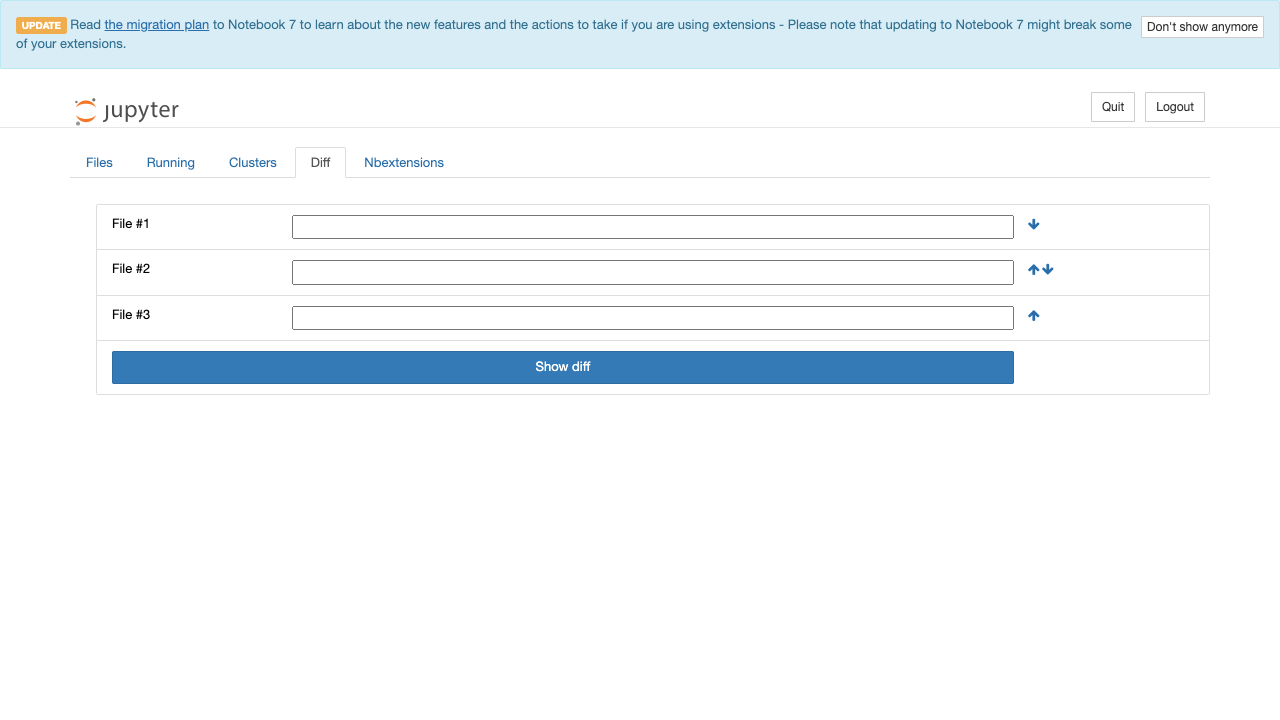

In [21]:
async def _step(page):
    # Verify that 3 input fields exist (from main.js:44-91)
    # Input IDs are diff-file0, diff-file1, diff-file2 (from main.js:89)
    file_input_0 = page.locator('#diff-file0')
    await expect(file_input_0).to_be_visible(timeout=transition_timeout)
    
    file_input_1 = page.locator('#diff-file1')
    await expect(file_input_1).to_be_visible(timeout=transition_timeout)
    
    file_input_2 = page.locator('#diff-file2')
    await expect(file_input_2).to_be_visible(timeout=transition_timeout)
    
    print("Found 3 file input fields")
    
    # Verify that Show Diff button is visible (from main.js:94-97)
    # Button ID is diff-search
    show_diff_button = page.locator('#diff-search')
    await expect(show_diff_button).to_be_visible(timeout=transition_timeout)
    
    print("Show Diff button is visible")

await run_pw(_step)

## Enter notebook paths and click Show Diff

Start epoch: 1763115152.64756 seconds
Entered 01.ipynb in File #1
Entered 01-r1.ipynb in File #2
Clicked Show Diff button


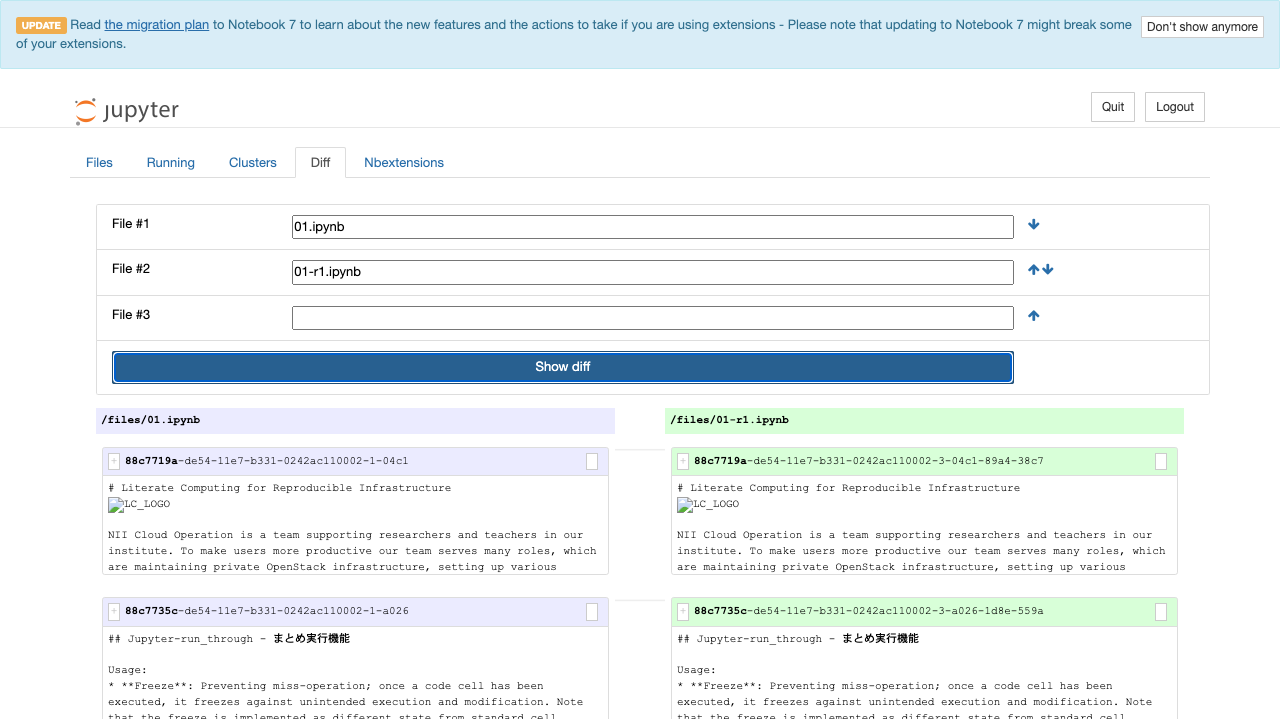

In [22]:
async def _step(page):
    # Fill first input with 01.ipynb
    file_input_0 = page.locator('#diff-file0')
    await file_input_0.fill('01.ipynb')
    print("Entered 01.ipynb in File #1")
    
    # Fill second input with 01-r1.ipynb
    file_input_1 = page.locator('#diff-file1')
    await file_input_1.fill('01-r1.ipynb')
    print("Entered 01-r1.ipynb in File #2")
    
    # Click Show Diff button
    show_diff_button = page.locator('#diff-search')
    await show_diff_button.click()
    
    print("Clicked Show Diff button")

await run_pw(_step)

## Verify that diff content is displayed

Start epoch: 1763115152.985564 seconds
Diff content is visible
Diff wrapper is visible
Diff view is displaying 39 cells correctly


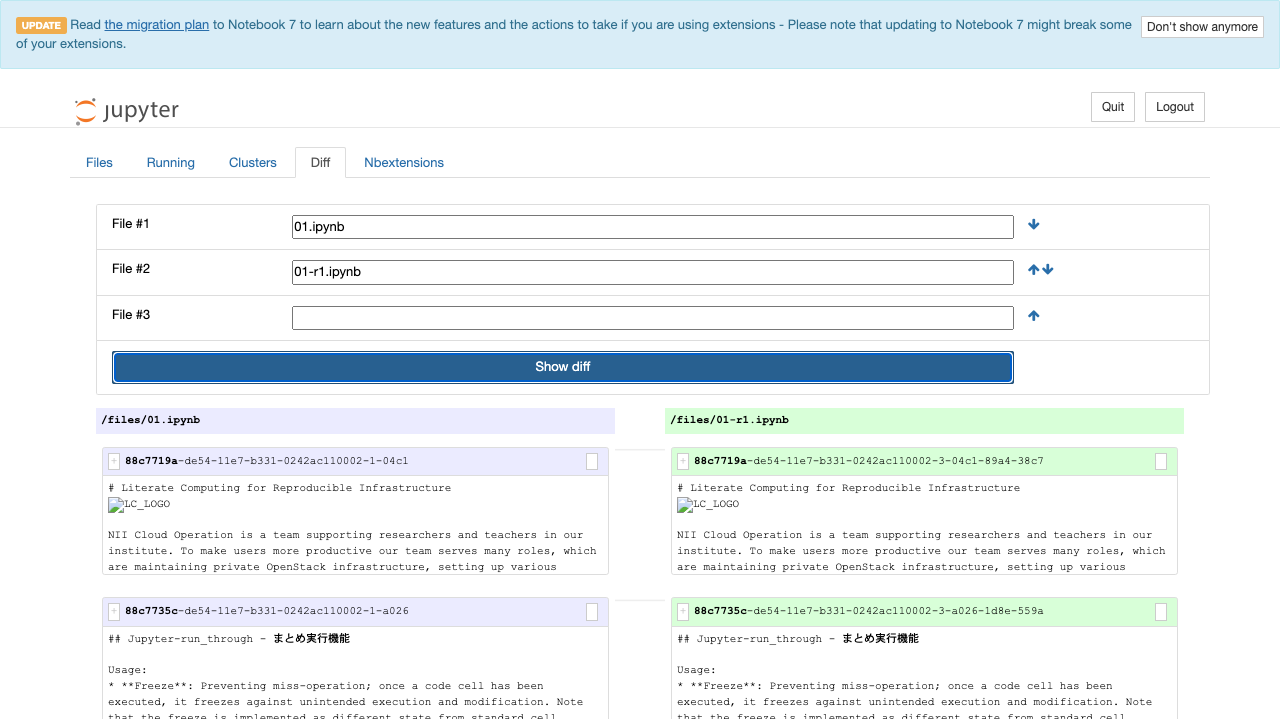

In [23]:
async def _step(page):
    # Verify that diff widget is visible (from main.js:176-179)
    # Diff content has id="diff-content" and class="jupyter-notebook-diff"
    diff_content = page.locator('#diff-content.jupyter-notebook-diff')
    await expect(diff_content).to_be_visible(timeout=transition_timeout)
    
    print("Diff content is visible")
    
    # Verify that wrapper element exists (from DiffView.ts:308)
    wrapper = page.locator('#diff-content .wrapper')
    await expect(wrapper).to_be_visible(timeout=transition_timeout)
    
    print("Diff wrapper is visible")
    
    # Verify that cell elements are rendered
    # 01.ipynb has 19 cells, 01-r1.ipynb has 20 cells, so total 39 cells
    cells = page.locator('#diff-content .cell')
    await expect(cells).to_have_count(39, timeout=transition_timeout)
    
    print("Diff view is displaying 39 cells correctly")

await run_pw(_step)

## Clean up

In [24]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpv8sr63dc/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpv8sr63dc/har.zip
Console log: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpv8sr63dc/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/Jupyter-LC_notebook_diff/ui-tests/e2e-notebook/notebooks/scripts/playwright.py", line 254, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmppj4idey7/videos/dc3ba9b7aca5d35a20e1caf8b6260db2.webm'


In [25]:
!rm -fr {work_dir}